In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

print("--- Verinin İlk 5 Satırı ---")
print(df.head())
X = df.iloc[:, [3, 4]].values

--- Verinin İlk 5 Satırı ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

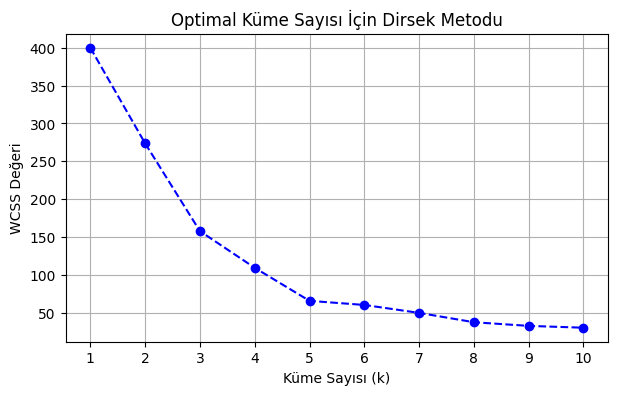

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--", color="b")
plt.title("Optimal Küme Sayısı İçin Dirsek Metodu")
plt.xlabel("Küme Sayısı (k)")
plt.ylabel("WCSS Değeri")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
df["Cluster"] = y_kmeans

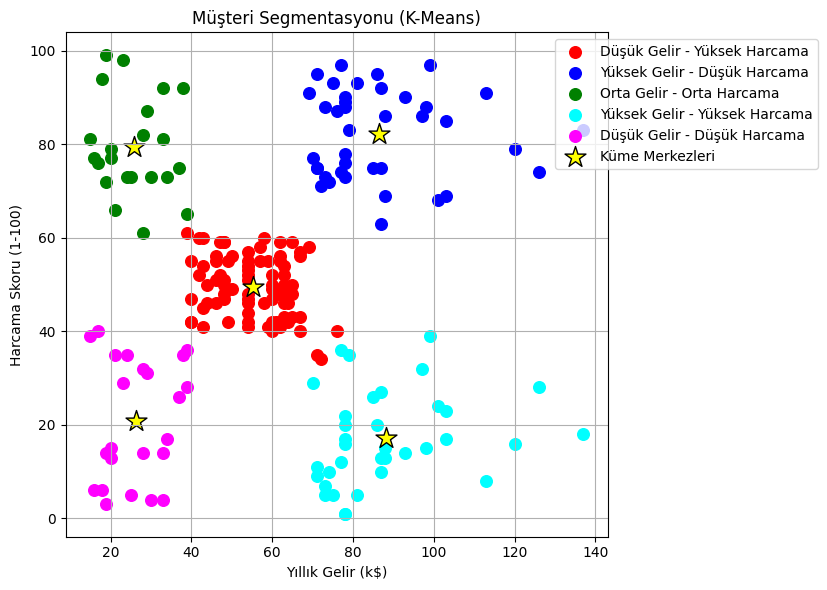

In [ ]:
plt.figure(figsize=(9, 6))

colors = ["red", "blue", "green", "cyan", "magenta"]
cluster_labels = [
    "Düşük Gelir - Yüksek Harcama",
    "Yüksek Gelir - Düşük Harcama",
    "Orta Gelir - Orta Harcama",
    "Yüksek Gelir - Yüksek Harcama",
    "Düşük Gelir - Düşük Harcama",
]

for i in range(optimal_k):
    plt.scatter(
        X[y_kmeans == i, 0],
        X[y_kmeans == i, 1],
        s=70,
        c=colors[i],
        label=cluster_labels[i],
    )

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    label="Küme Merkezleri",
)

plt.title("Müşteri Segmentasyonu (K-Means)")
plt.xlabel("Yıllık Gelir (k$)")
plt.ylabel("Harcama Skoru (1-100)")
plt.legend(loc="upper right", bbox_to_anchor=(1.4, 1))
plt.grid(True)
plt.tight_layout()
plt.show()